In [1]:
import pickle
import introns
#import importlib
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
from Bio import SeqIO

from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF

#importlib.reload(introns)

In [2]:
genome, genes = introns.HELP_load_default_genome_genes()

Creating genes, sequences, introns, exons and introns' class prediction


100%|██████████| 117/117 [00:00<00:00, 609.64it/s]


[CREATE] Genes, sequences, introns, exons created, introns' classes predicted
predict_all_introns checkpoint 1/4
predict_all_introns checkpoint 2/4
predict_all_introns checkpoint 3/4
predict_all_introns checkpoint 4/4


In [3]:
for gene_name, gene in genes.items():
    if len(gene.sequence)!=gene.length():
        print("No gene sequence", gene)
    for exon in gene.exons:
        if len(exon.sequence)!=exon.length():
            print("No exon sequence", exon)
    for intron in gene.introns:
        if len(intron.sequence)!=intron.length():
            print("No intron sequence", intron)

In [4]:
for gene_name, gene_obj in genes.items():
    for intron in gene_obj.introns:
        intron.add_test_annotation()

In [5]:
manannotation_K_NK_I_NN = [0, 0, 0, 0]

for gene_name, gene_obj in genes.items():
    for intron in gene_obj.introns:
        if intron.man_annotation == 'intron_NK':
            manannotation_K_NK_I_NN[1] += 1
        elif intron.man_annotation == 'intron_K':
            manannotation_K_NK_I_NN[0] += 1
        elif intron.man_annotation == 'intron_I':
            manannotation_K_NK_I_NN[2] += 1
        else:
            manannotation_K_NK_I_NN[3] += 1
        

print(f'manual annotation intron K/NK/I/NN: {manannotation_K_NK_I_NN}')

manual annotation intron K/NK/I/NN: [348, 325, 7, 1]


In [6]:
testannotation_K_NK_I_NN = [0, 0, 0, 0]

for gene_name, gene_obj in genes.items():
    for intron in gene_obj.introns:
        if intron.test_annotation == 'intron_NK':
            testannotation_K_NK_I_NN[1] += 1
        elif intron.test_annotation == 'intron_K':
            testannotation_K_NK_I_NN[0] += 1
        elif intron.test_annotation == 'intron_I':
            testannotation_K_NK_I_NN[2] += 1
        elif intron.test_annotation == 'intron_NN':
            testannotation_K_NK_I_NN[3] += 1
        else:
            print(intron.test_annotation)
            testannotation_K_NK_I_NN[3] += 1
        

print(f'test annotation intron K/NK/I/NN: {testannotation_K_NK_I_NN}')


test annotation intron K/NK/I/NN: [349, 296, 0, 36]


In [7]:
testglobalannotation_K_NK_I_NN = [0, 0, 0, 0]

for gene_name, gene_obj in genes.items():
    for intron in gene_obj.introns:
        if intron.test_global_annotation == 'intron_NK':
            testglobalannotation_K_NK_I_NN[1] += 1
        elif intron.test_global_annotation == 'intron_K':
            testglobalannotation_K_NK_I_NN[0] += 1
        elif intron.test_global_annotation == 'intron_I':
            testglobalannotation_K_NK_I_NN[2] += 1
        elif intron.test_global_annotation == 'intron_NN':
            testglobalannotation_K_NK_I_NN[3] += 1
        else:
            print(intron.test_global_annotation)
            testglobalannotation_K_NK_I_NN[3] += 1

print(f'test global annotation intron K/NK/I/NN: {testglobalannotation_K_NK_I_NN}')


test global annotation intron K/NK/I/NN: [148, 319, 56, 158]


In [8]:
print(manannotation_K_NK_I_NN,
testannotation_K_NK_I_NN,
testglobalannotation_K_NK_I_NN)

[348, 325, 7, 1] [349, 296, 0, 36] [148, 319, 56, 158]


In [9]:
for gene_name, gene_obj in genes.items():
    for intron in gene_obj.introns:
        print(f"\n\t\t{intron}")
        for k,v in intron.__dict__.items():
            print(f"{k}:::\t{v}")
    break


		
    Intron in gene: EL|STRG.5113.1|scaffold_3161:4719-42082
    scaff loc: 615-4197
    gene loc: 111=3693
__scaffold_name:::	EL|STRG.5113.1|scaffold_3161:4719-42082
__scaffold_start:::	615
__scaffold_end:::	4197
__sequence:::	GTGTGTGGGTGCGTGTGCGCCCATGTNNNNNNNNNNNNNNNNNTCACATGCACACTTACGTGTGCATGTGTGTGTGTGTGTGTATGTGTGCTTACATGTGCATATATGTGTGTGTGTGTCCTTATGTGTGTGTGTCTGCTTATGTGTGTGTATGTGTGCTTAAGTGTGCATGTGTGTGTGTGTGCGTATGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGGGTGTGTGTGTGTGCTTAATGTGCTTTTCGGAGAGTCGGCCATGGTGTGCACAGCTGGGCAGGGCCGTGGCAAAGATGCTCTCCCAGGCGATGCAGGGAGACCCGACTCGGCTGCTGGAAGCGCAGCTGTGGGACTTAAAGCGTGAGGCAGCCGCCCTGACGAAGATGATCGAGGACGCAGAGCTCCAGGGCCAGGCCGCCGAGCGTGCGTCCTCCCAGGGGACCCAGGGCAGATGTGAACAGGAACGGCCTGATTGCCCCCCTTCCAGGAGGGGGGGGGGTCCCCTCGGTCTTCTCTTTTCAGGTGGCTGTGAAAAATGGGCCAAAATTTTTTCGGCACAAAGAAAACGAAAATTTTCCTCCTTGCTTTCCATGTAGCGGCCTTGAACCATCAGGTGGTTCCCACCTGAGGCTGCATTTGTACGTGCACTTGTAGATAATTTATATTTTATTTTCATATAAATTCATTAAAAAAATTATTTCCATTTTTAGCTGCATCGCATGAGGCATCAGGATTCCATTTATATCTTTTATTGAAT

In [10]:
g = list(genes.values())[0]
e = g.exons[0]


for k,v in e.__dict__.items():
    print(f"{k}:::\t{v}")

scaffold_name:::	EL|STRG.5113.1|scaffold_3161:4719-42082
scaffold_start:::	504
scaffold_end:::	615
sequence:::	CCTTTCCTTTTCCTCCACATGAAGCTGGACGCCAGCTTGTTACGTTTCCTGGATGATGACCATTGGCAAGTGCTGATGGCTGTGGAACAGGGGATGAAGAACCATGAGCTG
strand:::	+
prev_intron:::	None
next_intron:::	
    Intron in gene: EL|STRG.5113.1|scaffold_3161:4719-42082
    scaff loc: 615-4197
    gene loc: 111=3693
gene:::	
    Gene EL|STRG.5113.1|scaffold_3161:4719-42082
    scaff loc: 504-37862
prev_exon:::	None
next_exon:::	
    Exon in gene: EL|STRG.5113.1|scaffold_3161:4719-42082
    scaff loc: 4197-4262


In [11]:
introns_K_demulti, introns_NK_demulti = introns.get_introns_demulti(genes)

Intron_K 348
Intron_NK 325
intron_I 7
introns_K_demulti 291
introns_NK_demulti 283


In [12]:
len(introns_NK_demulti), len(introns_K_demulti)

(283, 291)

In [13]:
def plot_correct_positions(introns_set, tit, nk_or_k = "NK"):
    if nk_or_k == "NK":
        class_to_check = 1
    elif nk_or_k == "K":
        class_to_check = 0
    else:
        "Incorrrect intron class; allowed are NK or K"
    correct_primary_pos, correct_variations, correct_full = 0, 0, 0
    incorrect_primary_pos_list, incorrect_variations_list, incorrect_full_list = [], [], []
    for intron in introns_set:
        intron_is_Xconv, correct_pos = False, False
        if intron.ML_class[class_to_check]:
            intron_is_Xconv = True
            correct_primary_pos +=1
        if True not in [v.ML_class[class_to_check] for v in intron.variations]:
            correct_pos = True
            correct_variations += 1
        #print(intron.ML_class[class_to_check], class_to_check, intron_is_Xconv)
        
        if intron_is_Xconv and correct_pos:
            correct_full +=1
        elif intron_is_Xconv and not correct_pos:
            incorrect_variations_list.append(intron)
        elif not intron_is_Xconv and correct_pos:
            incorrect_primary_pos_list.append(intron)
        else: #not v1 and not v2
            incorrect_full_list.append(intron)
            
    plt.figure(figsize=(10,5))
    plt.bar(["primary position\nidentified\nas %s" %nk_or_k,
            "other variants are not\nclassified as %s\n(primary excluded)" %nk_or_k,
            "primary position\nis the only one\nout of all variants to\nbe classified as %s" %nk_or_k,
            "# of all introns"],
            [correct_primary_pos, correct_variations, correct_full, len(introns_set)])
    for i, n in enumerate([correct_primary_pos, correct_variations, correct_full, len(introns_set)]):
            plt.text(i-0.25, n+5, "{:.2f}% ({})".format(n/len(introns_set)*100, n))
    plt.title(f"Classifying {tit} introns' positions with GaussianProcessClassifier")
    plt.show()

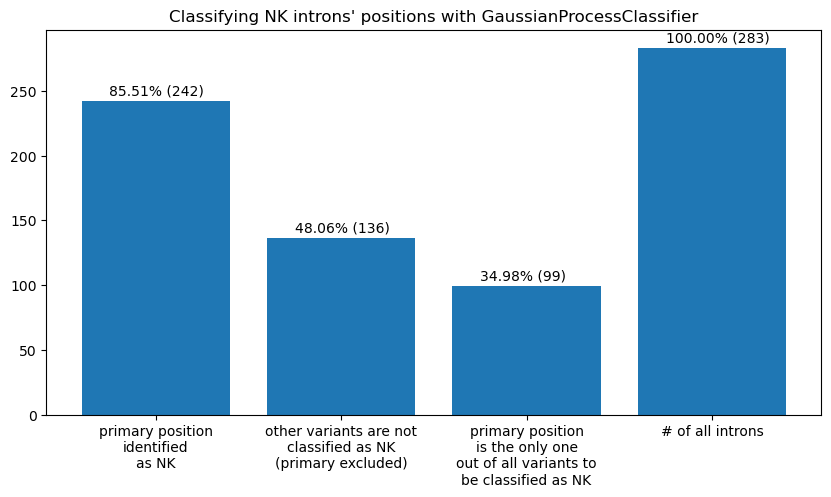

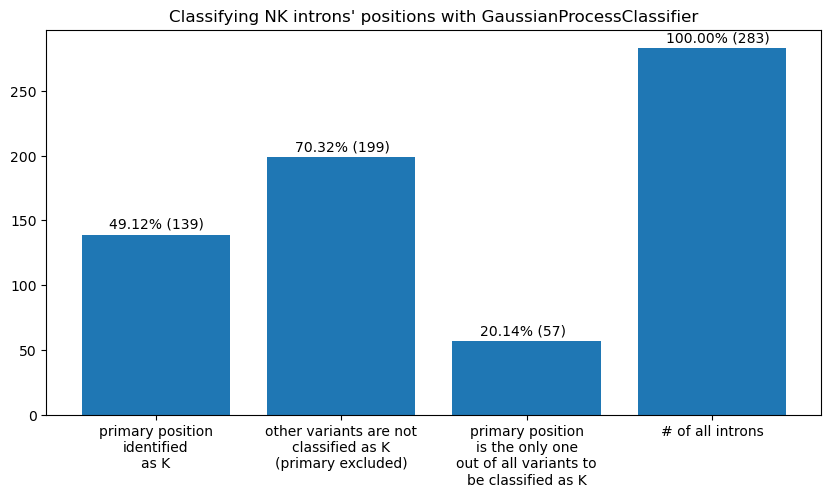

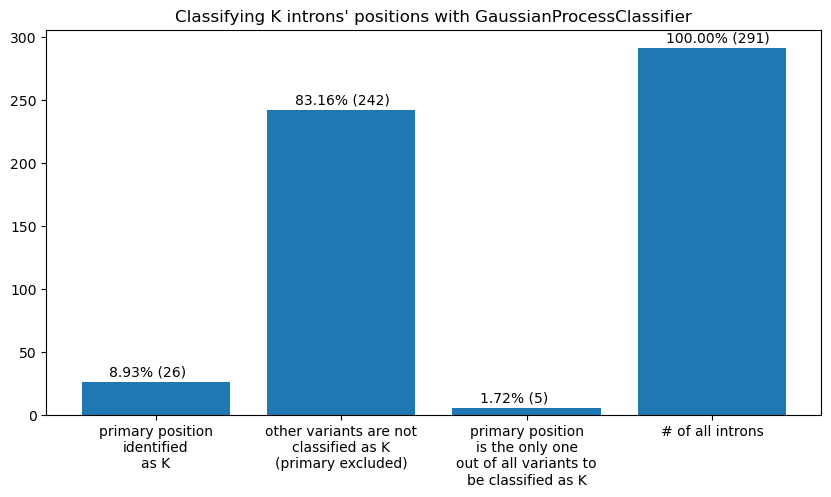

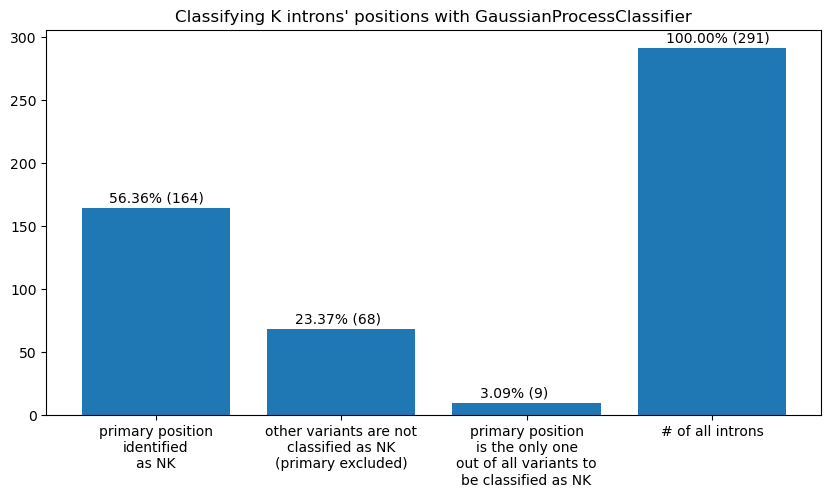

In [14]:
plot_correct_positions(introns_NK_demulti, tit = "NK", nk_or_k = "NK")
plot_correct_positions(introns_NK_demulti, tit = "NK", nk_or_k = "K")
plot_correct_positions(introns_K_demulti, tit = "K", nk_or_k = "K")
plot_correct_positions(introns_K_demulti, tit = "K", nk_or_k = "NK")

In [15]:
i_NK_K = 0
for intron in introns_NK_demulti:
    if intron.ML_class == [1, 1]:
        i_NK_K += 1
print(i_NK_K)

0
